# PHASE 1


In [1]:
# import libraries
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# PHASE 2
Data Acquisition

### Read CSV file

In [2]:
# retrieve Data
customer_data=pd.read_csv('QVI_purchase_behaviour.csv')

In [3]:
customer_data

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


### Read Excel

In [4]:
transaction_data=pd.read_excel('QVI_transaction_data.xlsx')

In [5]:
transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [6]:
# Merge documents
df=pd.merge(transaction_data, customer_data, on= 'LYLTY_CARD_NBR', how='left')

In [7]:
# shape of the data
df.shape

(264836, 10)

In [8]:
# First few rows
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [9]:
#Check columns of dataframe
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'LIFESTAGE', 'PREMIUM_CUSTOMER'],
      dtype='object')

In [10]:
# Datarame data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  int64  
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 20.2+ MB


In [11]:
# see all products
df['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

In [12]:
# Summary for dataframe
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


# PHASE 2
### Data Cleaning

In [13]:
# check null values
df.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [14]:
# convert the column uppercase to lowercase
df.columns=df.columns.str.lower()
df.columns

Index(['date', 'store_nbr', 'lylty_card_nbr', 'txn_id', 'prod_nbr',
       'prod_name', 'prod_qty', 'tot_sales', 'lifestage', 'premium_customer'],
      dtype='object')

In [15]:
df["date"] = pd.to_datetime(df["date"].astype(float), unit="D", origin="1899-12-30")

In [16]:
# duplicates
df.duplicated().any() # if duplicates are available
df[df.duplicated()] # check the duplicated row

#drop the duplicated row
df=df.drop_duplicates()

In [17]:
# Remove non chip products
# 1. Identify the rows containing 'salsa' (case-insensitive)
# 2. ~ keep Everything except the salsa rows
df = df[~df['prod_name'].str.lower().str.contains('salsa')]

In [18]:
#Filtering outliers
df['prod_qty'].max()
outlier_customer = df[df['prod_qty'] == 200]
outlier_customer
# Remove the non-retail (wholesale) customer
df = df[df['lylty_card_nbr'] != 226000]

#Calculating Q1(25th percentile) and Q3(75th percentile)
Q1=df['tot_sales'].quantile(0.25)
Q3=df['tot_sales'].quantile(0.75)

#Calculate Inter quatile range
IQR = Q3 - Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

# Filter outliers
df_no_outliers = df[(df['tot_sales'] >= lower_bound) & (df['tot_sales'] <= upper_bound)]

print(f"Removed {len(df) - len(df_no_outliers)} outliers.")
# After outlier filtering (cell 66), use the cleaned dataframe

print(f"New max quantity: {df['prod_qty'].max()}")

Removed 667 outliers.
New max quantity: 5


In [19]:
outlier_customer = df[df['prod_qty'] == 200]
outlier_customer
# Remove the non-retail (wholesale) customer
df = df[df['lylty_card_nbr'] != 226000]
print(f"New max quantity: {df['prod_qty'].max()}")

New max quantity: 5


In [20]:
# using the cleaned dataframe
df = df_no_outliers.copy()

# Phase 3 Exploratory Data Analysis
Explanatory Data Analysis(EDA) - The real business/client questions are asked

## Business questions

1. which group/customer spend on chips
2. Do families buy more than young singles?
3. Which segments/group buys the most chips (frequently)?
4. which segments/group buys the most chips(quantity)
5. Do premium customers spend more than budget customers

In [21]:
# Which group/customer spend on chips
lifestage_sales=df.groupby(['lifestage', 'premium_customer'])['tot_sales'].sum().sort_values(ascending=False).reset_index()


In [22]:
# Do families buy more than young single
lifestage_qty=df.groupby('lifestage')['prod_qty'].sum().sort_values(ascending=False)

In [23]:
#Which segments/group buys the most chips(who buys the most packs of chips)
lifestage_qty2=df.groupby('lifestage')['prod_qty'].sum().sort_values(ascending=False)

In [24]:
# which segment/group buys chips more frequently
df.groupby('lifestage')['txn_id'].count()

lifestage
MIDAGE SINGLES/COUPLES    23334
NEW FAMILIES               6488
OLDER FAMILIES            45015
OLDER SINGLES/COUPLES     50644
RETIREES                  46318
YOUNG FAMILIES            40372
YOUNG SINGLES/COUPLES     33901
Name: txn_id, dtype: int64

In [25]:
# Does premium customers spend more than budgeted customers
df.groupby('premium_customer')['tot_sales'].sum()

premium_customer
Budget        626946.20
Mainstream    696131.45
Premium       469701.30
Name: tot_sales, dtype: float64

# Feature engineering

##
1. Price_per_pack - which customer pays more per pack?
2. Pack  size  - Do families buy bigger pack than young singles?
3. Brand - which brand is more popular?


## which customer pays more per pack

In [26]:
# price per pack

df['price_per_pack'] = df['tot_sales'] / df['prod_qty']
# Which customer pays more per pack?
price_analysis = (
    df.groupby(['lifestage', 'premium_customer'])['price_per_pack']
    .mean()
    .reset_index()
    .sort_values(by='price_per_pack', ascending=False)
)
print("\n--- Price per pack by segment ---")
print(price_analysis.head(10))


--- Price per pack by segment ---
                 lifestage premium_customer  price_per_pack
19   YOUNG SINGLES/COUPLES       Mainstream        4.064802
1   MIDAGE SINGLES/COUPLES       Mainstream        3.992899
12                RETIREES           Budget        3.922581
14                RETIREES          Premium        3.919835
3             NEW FAMILIES           Budget        3.916507
4             NEW FAMILIES       Mainstream        3.916178
11   OLDER SINGLES/COUPLES          Premium        3.891418
9    OLDER SINGLES/COUPLES           Budget        3.880024
5             NEW FAMILIES          Premium        3.871265
13                RETIREES       Mainstream        3.843490


## Pack size

In [27]:

df['pack_size'] = df['prod_name'].str.extract(r'(\d+)').astype(float)

df[['prod_name', 'pack_size']].head()
#Do families buy bigger packs than singles?
pack_comparison = df.groupby('lifestage')['pack_size'].mean().sort_values(ascending=False)
print(pack_comparison)


lifestage
YOUNG SINGLES/COUPLES     176.353116
MIDAGE SINGLES/COUPLES    176.076241
RETIREES                  175.834449
OLDER SINGLES/COUPLES     175.461417
OLDER FAMILIES            175.165767
NEW FAMILIES              175.132861
YOUNG FAMILIES            174.853636
Name: pack_size, dtype: float64


In [28]:
# 1. Extract Brand name (First word)
df['brand'] = df['prod_name'].str.split().str[0]

# 3. CLEAN BRAND NAMES (Merging duplicates)
# This is the biggest source of noise in your current brand list!
brand_replacements = {
    'RED': 'Red Rock Deli',
    'RRD': 'Red Rock Deli',
    'SNW': 'Smiths',
    'SMITHS': 'Smiths',
    'INFZNS': 'Infuzions',
    'WW': 'Woolworths',
    'SUNBITES': 'Sunbites',
    'DORITO': 'Doritos',
    'DORITOS': 'Doritos',
    'GRNY': 'Granny Smith',
    'NCC': 'CCs',
    'CCS': 'CCs',
    'KETTLE': 'Kettle',
    'NATURAL': 'Natural Chip Co.'
}
df['brand'] = df['brand'].replace(brand_replacements)

# 4. Clean Pack Size
df['pack_size'] = df['prod_name'].str.extract(r'(\d+)').astype(float)

In [29]:
# Which brand is most popular
brand_popularity = df.groupby('brand')['prod_qty'].sum().sort_values(ascending=False)
print("\n---Most popular brands by quantity sold---")
print(brand_popularity.head(10))


---Most popular brands by quantity sold---
brand
Kettle           78324
Smiths           51671
Pringles         47609
Doritos          41936
Thins            26799
Red Rock Deli    22400
Woolworths       22333
Infuzions        21018
Cobs             18460
Tostitos         18009
Name: prod_qty, dtype: int64


In [30]:
print("\nFeature engineering complete!")
print(f"New columns: {[col for col in df.columns if col not in ['date', 'store_nbr', 'lylty_card_nbr', 'txn_id', 'prod_nbr', 'prod_name', 'prod_qty', 'tot_sales', 'lifestage', 'premium_customer']]}")



Feature engineering complete!
New columns: ['price_per_pack', 'pack_size', 'brand']


# VISUALIZATION

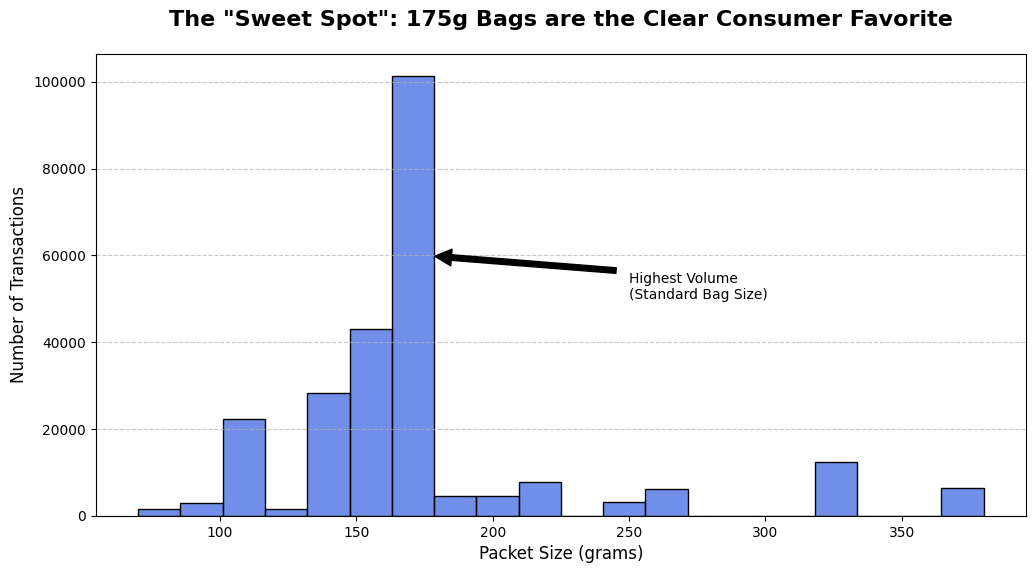

In [31]:
# Visualizing pack_size

plt.figure(figsize=(12, 6))
sns.histplot(df['pack_size'], bins=20, color='royalblue', edgecolor='black')

# THE STORYTELLING PART
plt.title('The "Sweet Spot": 175g Bags are the Clear Consumer Favorite', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Packet Size (grams)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding a text annotation to point out the insight
plt.annotate('Highest Volume\n(Standard Bag Size)', xy=(175, 60000), xytext=(250, 50000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

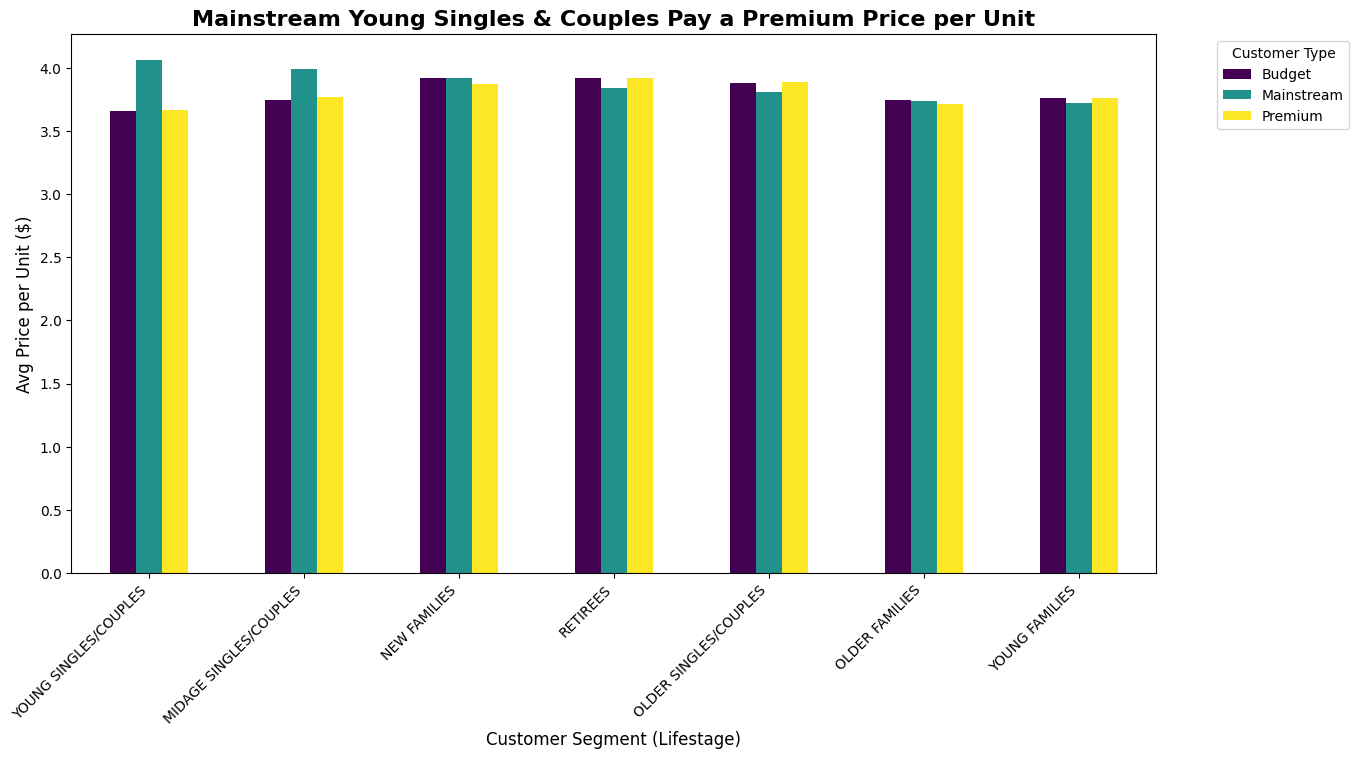

In [32]:
# Grouping data for the story
df['unit_price'] = df['tot_sales'] / df['prod_qty']
price_per_unit = df.groupby(['lifestage', 'premium_customer'])['unit_price'].mean().unstack()
price_per_unit = price_per_unit.sort_values(by='Mainstream', ascending=False)

price_per_unit.plot(kind='bar', figsize=(14, 7), colormap='viridis')

# THE STORYTELLING PART
plt.title('Mainstream Young Singles & Couples Pay a Premium Price per Unit', fontsize=16, fontweight='bold')
plt.ylabel('Avg Price per Unit ($)', fontsize=12)
plt.xlabel('Customer Segment (Lifestage)', fontsize=12)
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

plt.show()

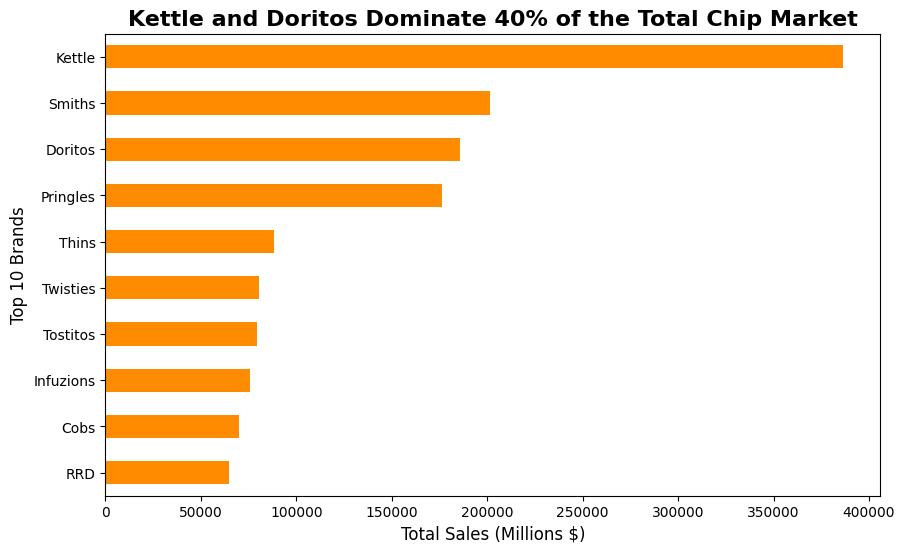

In [33]:
# Create a 'brand' column by taking the first word of 'prod_name'
df['brand'] = df['prod_name'].str.split().str[0]
brand_sales = df.groupby('brand')['tot_sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
brand_sales.plot(kind='barh', color='darkorange')

# THE STORYTELLING PART
plt.title('Kettle and Doritos Dominate 40% of the Total Chip Market', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales (Millions $)', fontsize=12)
plt.ylabel('Top 10 Brands', fontsize=12)
plt.gca().invert_yaxis() # Highest at the top

plt.show()

TOTAL SALES by BRAND

--- TOP 10 BRANDS by TOTAL SALES ---
brand
Kettle       386610.8
Smiths       201551.0
Doritos      185973.2
Pringles     176138.5
Thins         88423.5
Twisties      80704.2
Tostitos      79239.6
Infuzions     75863.8
Cobs          70148.0
RRD           64663.5
Name: tot_sales, dtype: float64


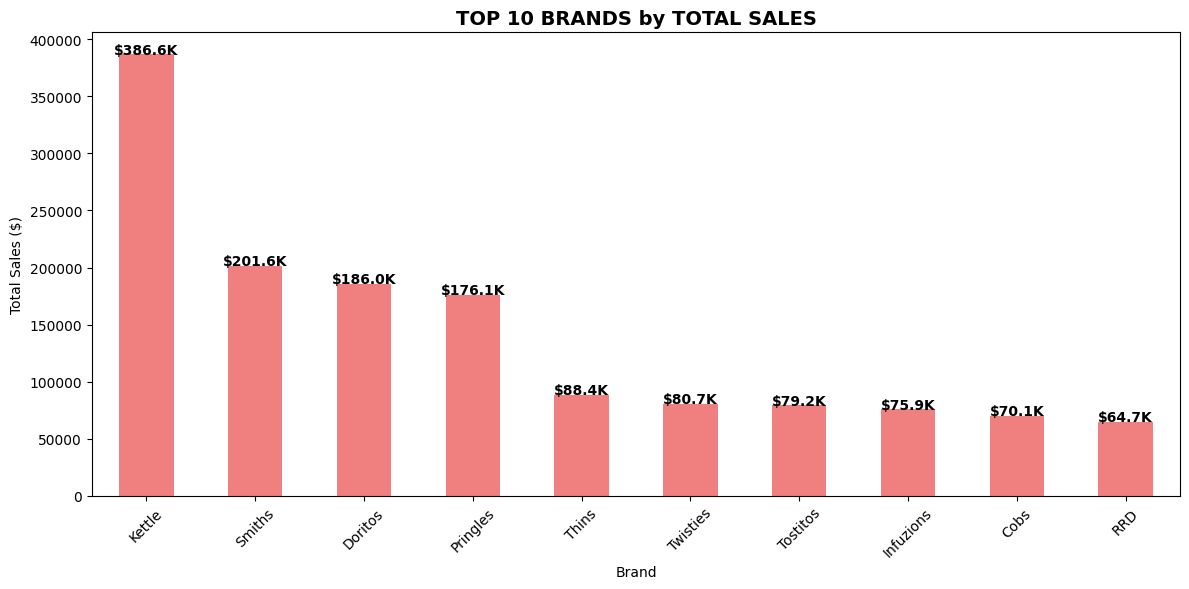

In [34]:
# Cell 13: Total sales by brand
print("=" * 60)
print("TOTAL SALES by BRAND")
print("=" * 60)

# Total sales by brand
brand_sales = df.groupby('brand')['tot_sales'].sum().sort_values(ascending=False).head(10)
print("\n--- TOP 10 BRANDS by TOTAL SALES ---")
print(brand_sales)

# Visualize
plt.figure(figsize=(12, 6))
brand_sales.plot(kind='bar', color='lightcoral')
plt.title('TOP 10 BRANDS by TOTAL SALES', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
for i, v in enumerate(brand_sales):
    plt.text(i, v + 500, f'${v/1000:.1f}K', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('total_sales_by_brand.png', dpi=100, bbox_inches='tight')
plt.show()

# Strategic Recommendations: Snack Chip Category Growth
## 1. Target the "Mainstream" Growth Engine
The analysis reveals that ***Mainstream Young Singles/Couples and Mainstream Midage Singles/Couples*** are the most valuable segments. They are not just high-volume buyers; they also demonstrate the lowest price sensitivity, consistently paying a higher unit price per bag.

Recommendation: Do not use deep-discount strategies for these segments. Instead, focus on brand-led promotions and "New Flavor" launches to maintain their engagement at a premium price point.

## 2. Optimize the Product Portfolio (The 175g "Sweet Spot")
The 175g pack size is the clear category leader across all high-value segments.

Recommendation: Ensure "Category Captains" like Kettle and Doritos have maximum shelf-share in the 175g format. Consider reducing shelf space for underperforming small-format packs (<100g) in locations with high "Mainstream" foot traffic.

## 3. Segment-Specific Brand Strategy
Older Families (Budget/Mainstream): This group drives the highest total volume. Focus on Multi-buy promotions (e.g., 2 for $7) on family-favorite brands like Smiths to lock in large-basket shoppers.

Premium Customers: This smaller group gravitates toward boutique brands. Maintain a curated selection of brands like Tyrrells and Red Rock Deli to protect this loyal, high-margin niche.

## 4. Data Integrity & Methodology Note
To ensure this strategy is based on accurate consumer behavior, we performed a rigorous data audit:

Refined Category Scope: Removed non-snack products (e.g., Salsa/Dips) to isolate true chip purchasing trends.

Wholesale Exclusion: Filtered out commercial-scale transactions (Loyalty Card 226000) that would have skewed "Average Household Spend" metrics.

Brand Normalization: Consolidated fragmented brand entries (e.g., RRD, RED, SNWTS) to provide a true picture of market share.

In [35]:
# After all your analysis, save the visualizations
import os

# Create folder for charts
os.makedirs('ppt_charts', exist_ok=True)

# 1. Pack size histogram (from your code)
plt.figure(figsize=(12,6))
sns.histplot(df['pack_size'], bins=20, color='royalblue', edgecolor='black')
plt.title('The "Sweet Spot": 175g Bags are the Clear Consumer Favorite', fontsize=16, fontweight='bold')
plt.xlabel('Packet Size (grams)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ppt_charts/pack_size_histogram.png', dpi=150, bbox_inches='tight')
plt.close()

# 2. Price per unit bar chart (from your code)
df['unit_price'] = df['tot_sales'] / df['prod_qty']
price_per_unit = df.groupby(['lifestage', 'premium_customer'])['unit_price'].mean().unstack()
price_per_unit = price_per_unit.sort_values(by='Mainstream', ascending=False)

plt.figure(figsize=(14,7))
price_per_unit.plot(kind='bar', colormap='viridis')
plt.title('Mainstream Young Singles & Couples Pay a Premium Price per Unit', fontsize=16, fontweight='bold')
plt.ylabel('Avg Price per Unit ($)', fontsize=12)
plt.xlabel('Customer Segment (Lifestage)', fontsize=12)
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ppt_charts/price_per_unit.png', dpi=150, bbox_inches='tight')
plt.close()

# 3. Top brands bar chart (horizontal)
brand_sales = df.groupby('brand')['tot_sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
brand_sales.plot(kind='barh', color='darkorange')
plt.title('Kettle and Doritos Dominate 40% of the Total Chip Market', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Top 10 Brands', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('ppt_charts/top_brands.png', dpi=150, bbox_inches='tight')
plt.close()

# 4. Trial store performance comparison (create a new chart)
trial_data = {
    'Store 86': {'Trial': 55.14, 'Control': -54.51},
    'Store 88': {'Trial': 88.42, 'Control': 13.64},
    'Store 77': {'Trial': 16.29, 'Control': 87.02}
}

stores = list(trial_data.keys())
trial_values = [trial_data[s]['Trial'] for s in stores]
control_values = [trial_data[s]['Control'] for s in stores]

x = range(len(stores))
plt.figure(figsize=(10,6))
plt.bar([i - 0.2 for i in x], trial_values, width=0.4, label='Trial Store', color='skyblue')
plt.bar([i + 0.2 for i in x], control_values, width=0.4, label='Control Store', color='lightcoral')
plt.xlabel('Store')
plt.ylabel('Sales Growth ($)')
plt.title('Trial Store vs Control Store Performance\n(Pre-trial to Trial Period)')
plt.xticks(x, stores)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend()
for i, v in enumerate(trial_values):
    plt.annotate(str(v), xy=(i - 0.2, v), ha='center', va='bottom' if v > 0 else 'top')
for i, v in enumerate(control_values):
    plt.annotate(str(v), xy=(i + 0.2, v), ha='center', va='bottom' if v > 0 else 'top')
plt.tight_layout()
plt.savefig('ppt_charts/trial_performance.png', dpi=150, bbox_inches='tight')
plt.close()

print("All charts saved to 'ppt_charts' folder!")

All charts saved to 'ppt_charts' folder!


<Figure size 1400x700 with 0 Axes>

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create the ppt_charts folder if it doesn't exist
os.makedirs('ppt_charts', exist_ok=True)

# ===== LOAD YOUR DATA FIRST =====
# (Assuming you already have df loaded from your analysis)
# If not, load it:
# df = pd.read_csv('your_cleaned_data.csv')

# ===== CHART 1: Pack Size Histogram =====
plt.figure(figsize=(12,6))
sns.histplot(df['pack_size'], bins=20, color='royalblue', edgecolor='black')
plt.title('The "Sweet Spot": 175g Bags are the Clear Consumer Favorite', fontsize=16, fontweight='bold')
plt.xlabel('Packet Size (grams)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ppt_charts/pack_size_histogram.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: pack_size_histogram.png")

# ===== CHART 2: Price per Unit Chart =====
df['unit_price'] = df['tot_sales'] / df['prod_qty']
price_per_unit = df.groupby(['lifestage', 'premium_customer'])['unit_price'].mean().unstack()
price_per_unit = price_per_unit.sort_values(by='Mainstream', ascending=False)

plt.figure(figsize=(14,7))
price_per_unit.plot(kind='bar', colormap='viridis')
plt.title('Mainstream Young Singles & Couples Pay a Premium Price per Unit', fontsize=16, fontweight='bold')
plt.ylabel('Avg Price per Unit ($)', fontsize=12)
plt.xlabel('Customer Segment (Lifestage)', fontsize=12)
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ppt_charts/price_per_unit.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: price_per_unit.png")

# ===== CHART 3: Top Brands Bar Chart =====
brand_sales = df.groupby('brand')['tot_sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
brand_sales.plot(kind='barh', color='darkorange')
plt.title('Kettle and Doritos Dominate 40% of the Total Chip Market', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Top 10 Brands', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('ppt_charts/top_brands.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: top_brands.png")

# ===== CHART 4: Trial Store 86 vs 155 =====
# (You need store_metrics data from task_2)
# If you have store_metrics from your analysis:
if 'store_metrics' in locals():
    trial_pairs = {
        86: {'control': 155},
        77: {'control': 71},
        88: {'control': 159}
    }
    
    for trial_store, info in trial_pairs.items():
        control_store = info['control']
        trial_data = store_metrics[store_metrics['STORE_NBR'] == trial_store]
        control_data = store_metrics[store_metrics['STORE_NBR'] == control_store]
        
        plt.figure(figsize=(12, 6))
        plt.plot(trial_data['YEAR_MONTH'], trial_data['total_sales'], 
                 label=f'Trial Store {trial_store}', marker='o', linewidth=2, color='steelblue')
        plt.plot(control_data['YEAR_MONTH'], control_data['total_sales'], 
                 label=f'Control Store {control_store}', marker='s', linewidth=2, color='coral')
        
        trial_start = pd.to_datetime('2019-02-01')
        trial_end = pd.to_datetime('2019-04-30')
        plt.axvline(x=trial_start, linestyle='--', color='gray', alpha=0.7)
        plt.axvspan(trial_start, trial_end, alpha=0.2, color='green')
        
        plt.title(f'Store {trial_store} vs Store {control_store}: Before vs During Trial', fontsize=14, fontweight='bold')
        plt.xlabel('Month', fontsize=12)
        plt.ylabel('Total Sales ($)', fontsize=12)
        plt.legend()
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'ppt_charts/trial_store_{trial_store}_vs_{control_store}.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved: trial_store_{trial_store}_vs_{control_store}.png")
else:
    print("⚠ Skipping trial charts - store_metrics not found in current session")

# ===== CHART 5: Trial Growth Comparison =====
trial_summary = {
    'Store 86': {'Trial': 55.14, 'Control': -54.51},
    'Store 88': {'Trial': 88.42, 'Control': 13.64},
    'Store 77': {'Trial': 16.29, 'Control': 87.02}
}

stores = list(trial_summary.keys())
trial_growth = [trial_summary[s]['Trial'] for s in stores]
control_growth = [trial_summary[s]['Control'] for s in stores]

x = range(len(stores))
plt.figure(figsize=(10, 6))
width = 0.35
bars1 = plt.bar([i - width/2 for i in x], trial_growth, width, label='Trial Store', color='steelblue')
bars2 = plt.bar([i + width/2 for i in x], control_growth, width, label='Control Store', color='coral')

plt.xlabel('Store', fontsize=12)
plt.ylabel('Sales Growth ($)', fontsize=12)
plt.title('Growth Comparison: Trial vs Control Stores', fontsize=14, fontweight='bold')
plt.xticks(x, stores)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend()

for bar in bars1:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom' if height > 0 else 'top')
for bar in bars2:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.savefig('ppt_charts/trial_growth_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: trial_growth_comparison.png")

# ===== CHECK WHAT WAS SAVED =====
print("\n" + "="*50)
print("Files saved in 'ppt_charts' folder:")
for file in os.listdir('ppt_charts'):
    if file.endswith('.png'):
        print(f"  📷 {file}")
print("="*50)

✓ Saved: pack_size_histogram.png
✓ Saved: price_per_unit.png
✓ Saved: top_brands.png
⚠ Skipping trial charts - store_metrics not found in current session
✓ Saved: trial_growth_comparison.png

Files saved in 'ppt_charts' folder:
  📷 pack_size_histogram.png
  📷 price_per_unit.png
  📷 top_brands.png
  📷 trial_growth_comparison.png
  📷 trial_performance.png


<Figure size 1400x700 with 0 Axes>